In [36]:
import pandas as pd

In [37]:
df = pd.read_csv('urls-dataset.csv')

In [38]:
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [39]:
df.shape

(549346, 2)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [41]:
df.Label.value_counts()

Label
good    392924
bad     156422
Name: count, dtype: int64

In [42]:
import sys
print(sys.executable)


d:\seminar project\myenv\Scripts\python.exe


In [43]:
!"/Library/Developer/CommandLineTools/usr/bin/python3" -m pip install nltk


The system cannot find the path specified.


In [44]:
import nltk
print("NLTK works perfectly!")


NLTK works perfectly!


In [45]:
from nltk.tokenize import RegexpTokenizer

In [46]:
tokenizer = RegexpTokenizer(r'[A-Za-z]+')

In [47]:
df.URL[0]

'nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526'

In [48]:
tokenizer.tokenize(df.URL[0])

['nobell',
 'it',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'login',
 'SkyPe',
 'com',
 'en',
 'cgi',
 'bin',
 'verification',
 'login',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'index',
 'php',
 'cmd',
 'profile',
 'ach',
 'outdated',
 'page',
 'tmpl',
 'p',
 'gen',
 'failed',
 'to',
 'load',
 'nav',
 'login',
 'access']

In [49]:
df['text_tokenized']= df.URL.map(lambda t: tokenizer.tokenize(t))

In [50]:
df.head()

,URL,Label,text_tokenized
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi..."


In [51]:
from nltk.stem.snowball import  SnowballStemmer
stemmer =  SnowballStemmer('english')

In [52]:
df['text_stem']=df['text_tokenized'].map(lambda l: [stemmer.stem(word)for word in l])

In [53]:
df.head()

,URL,Label,text_tokenized,text_stem
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide..."


In [54]:
df['text'] = df['text_stem'].map(lambda l: ' '.join(l))

In [55]:
df.head()

,URL,Label,text_tokenized,text_stem,text
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,...",nobel it ffb d dca cce f login skype com en cg...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into...",serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


In [56]:
good_sites = df[df.Label == 'good']
bad_sites = df[df.Label == 'bad']


In [57]:
good_sites.head()

,URL,Label,text_tokenized,text_stem,text
18231,esxcc.com/js/index.htm?us.battle.net/noghn/en/...,good,"[esxcc, com, js, index, htm, us, battle, net, ...","[esxcc, com, js, index, htm, us, battl, net, n...",esxcc com js index htm us battl net noghn en r...
18232,wwweira¯&nvinip¿ncH¯wVö%ÆåyDaHðû/ÏyEùuË\nÓ6...,good,"[www, eira, nvinip, ncH, wV, yDaH, yE, u, rT, ...","[www, eira, nvinip, nch, wv, ydah, ye, u, rt, ...",www eira nvinip nch wv ydah ye u rt u g m i xz...
18233,'www.institutocgr.coo/web/media/syqvem/dk-óij...,good,"[www, institutocgr, coo, web, media, syqvem, d...","[www, institutocgr, coo, web, media, syqvem, d...",www institutocgr coo web media syqvem dk ij r ...
18234,Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,good,"[Y, ko, D, l, qt]","[y, ko, d, l, qt]",y ko d l qt
18236,ruta89fm.com/images/AS@Vies/1i75cf7b16vc<Fd16...,good,"[ruta, fm, com, images, AS, Vies, i, cf, b, vc...","[ruta, fm, com, imag, as, vie, i, cf, b, vc, f...",ruta fm com imag as vie i cf b vc f d b g sd v...


In [58]:
import sys
print(sys.executable)


d:\seminar project\myenv\Scripts\python.exe


In [59]:
!"/Library/Developer/CommandLineTools/usr/bin/python3" -m pip install wordcloud


The system cannot find the path specified.


In [60]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

def plot_wordcloud(text, mask=None, max_words=400, max_font_size=120,
                   figure_size=(24.0, 16.0), title=None, title_size=40, image_color=False):
    # Stopwords
    stopwords = set(STOPWORDS)
    more_stopwords = ['com', 'http']
    stopwords = stopwords.union(more_stopwords)

    # Create WordCloud object
    wordcloud = WordCloud(
        background_color='white',
        stopwords=stopwords,
        max_words=max_words,
        max_font_size=max_font_size,
        random_state=42,
        mask=mask
    )

    # Generate word cloud
    wordcloud.generate(text)

    # Plot
    plt.figure(figsize=figure_size)

    if image_color and mask is not None:
        image_colors = ImageColorGenerator(mask)
        plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear")
    else:
        plt.imshow(wordcloud, interpolation="bilinear")

    # Title
    if title:
        plt.title(title, fontdict={'size': title_size, 'color': 'green', 'verticalalignment': 'bottom'})

    plt.axis('off')
    plt.tight_layout()
    plt.show()


In [61]:
all_text = ' '.join(good_sites['text'].tolist())

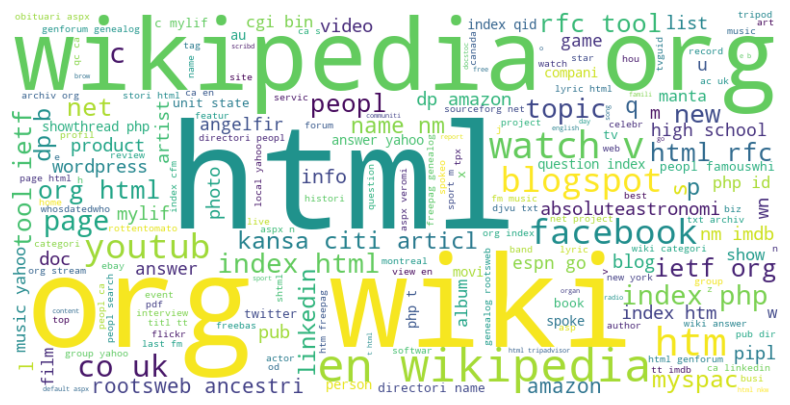

In [62]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

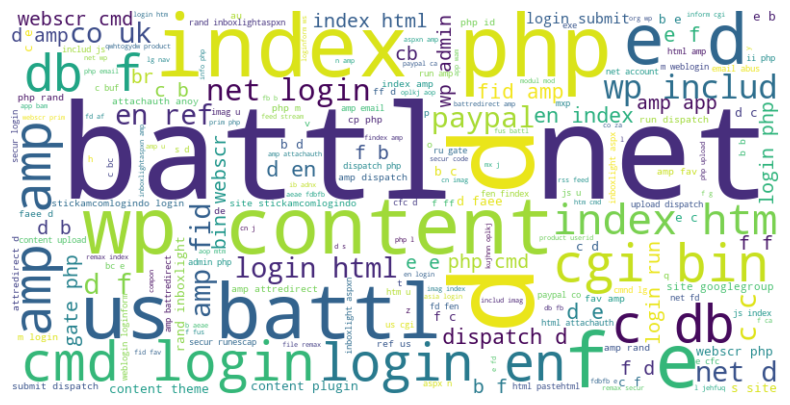

In [63]:
all_text = ' '.join(bad_sites['text'].tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [64]:
from sklearn.feature_extraction.text import CountVectorizer

cv =CountVectorizer()

features = cv.fit_transform(df.text)
features[:5].toarray()


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5, 350837))

In [65]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(features, df.Label, test_size=0.2)

In [66]:
from sklearn.linear_model import LogisticRegression

l_model = LogisticRegression()

l_model.fit(x_train, y_train)

d:\seminar project\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [67]:
l_model.score(x_test,y_test)

0.9645581141348867

In [68]:
l_model.score(x_train,y_train)

0.9791456188733856

In [69]:
from sklearn.metrics import classification_report

print('\nCLASSIFICATION REPORT\n')
print(classification_report(l_model.predict(x_test), y_test,
                            target_names =['Bad' ,'Good']))


CLASSIFICATION REPORT

              precision    recall  f1-score   support

         Bad       0.91      0.96      0.94     29491
        Good       0.99      0.96      0.98     80379

    accuracy                           0.96    109870
   macro avg       0.95      0.96      0.96    109870
weighted avg       0.97      0.96      0.96    109870



In [70]:
from sklearn.metrics import confusion_matrix
con_mat = pd.DataFrame(confusion_matrix(l_model.predict(x_test),y_test), 
                      index=['Actual:Bad', 'Actual:Good'], 
                      columns=['Predicted:Bad', 'Predicted:Good'])


In [71]:
!pip install seaborn



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



CONFUSION MATRIX



<Axes: >

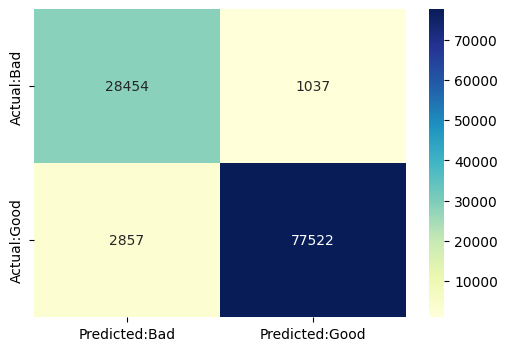

In [72]:

import seaborn as sns
import matplotlib.pyplot as plt

print('\nCONFUSION MATRIX\n')
plt.figure(figsize=(6,4))
sns.heatmap(con_mat, annot = True, fmt='d', cmap="YlGnBu")

In [73]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()
mnb.fit(x_train, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [74]:
mnb.score(x_test,y_test)

0.9582142532083371

In [75]:
import pickle 
pickle.dump(l_model, open('phising.pkl','wb'))

In [76]:
pickle.dump(cv, open('vectorizer.pkl','wb'))

In [77]:
pickle.dump(mnb, open('phising_mnb.pkl','wb'))